In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from shapely.geometry import box
import geopandas as gpd
from rasterio.features import geometry_mask
from osgeo import gdal




In [2]:
data_dir = os.path.join(os.getcwd(), '..', 'data')
coord_df = pd.read_excel(
    os.path.join(data_dir, 'Coordonnee eaux souterraines.xlsx'),
    engine='openpyxl', sheet_name='tout'
)
gis_dir = os.path.join(os.getcwd(), '..', 'gisfiles')
processed_gis_dir = os.path.join(gis_dir, 'processed_gis')

In [3]:
coord_df.head()

,nouveau ID,X,Y,nature,id mine,ancien ID
0,WGWP1,239466,1149531,piezo,GW001,WGW1
1,WGWP2,235634,1147856,piezo,GW002,WGW2
2,WGWP3,236222,1145671,piezo,GW003,WGW3
3,WGWP4,235804,1148991,piezo,GW0018,WGW4
4,WGWP5,239331,1147918,piezo,GW0017,WGW5


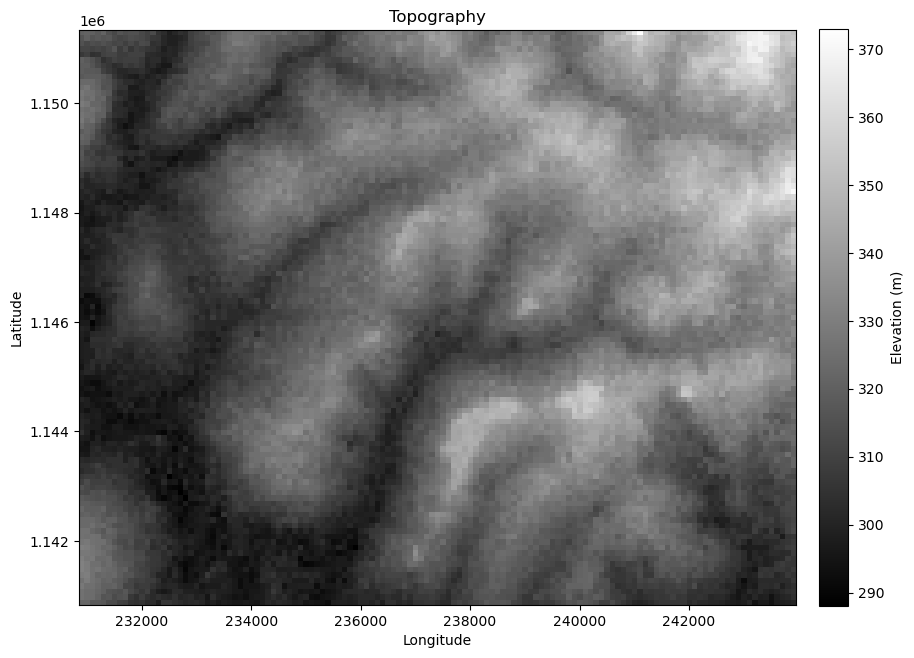

In [4]:
topo_file = os.path.join(data_dir, 'Rawdata', 'topo_nouveau', 'topo_Zone_vf.tif')
def plot_topo(topo_file):
    import rasterio
    from rasterio.plot import show

    with rasterio.open(topo_file) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        show(src, ax=ax, cmap='grey')
        im = ax.images[0]
        ax.set_title('Topography')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        fig.colorbar(
            im,
            ax=ax,
            label='Elevation (m)',
            shrink=0.75,
            fraction=0.045,
            pad=0.03,
        )
        plt.show()
plot_topo(topo_file)

Text(0.5, 1.0, 'Study Area')

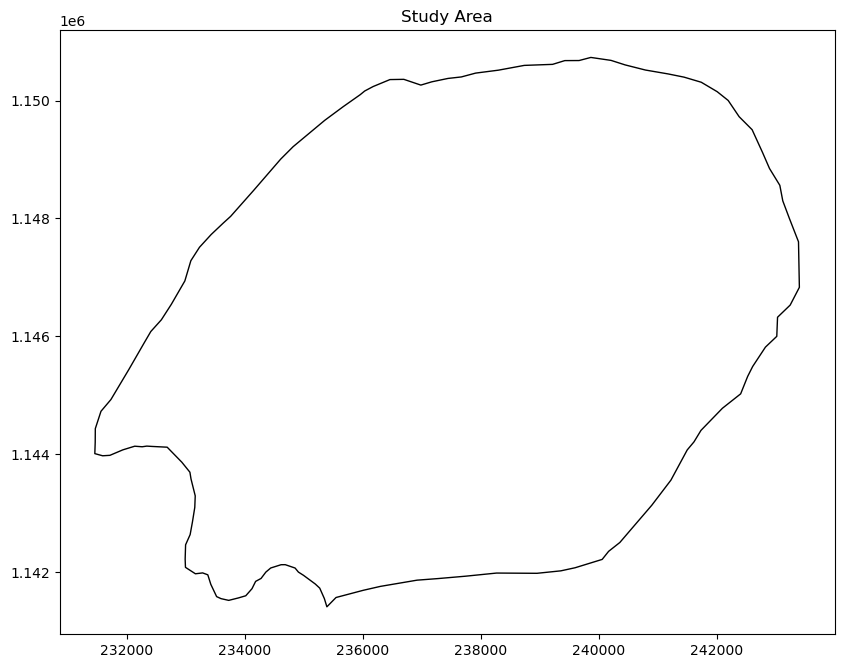

In [5]:
study_area = gpd.read_file(os.path.join(data_dir, 'Rawdata', 'limite_nouveau', 'zone_etude_vf.shp'))
study_area.plot(figsize=(10, 10), edgecolor='black', facecolor='none')
plt.title('Study Area')



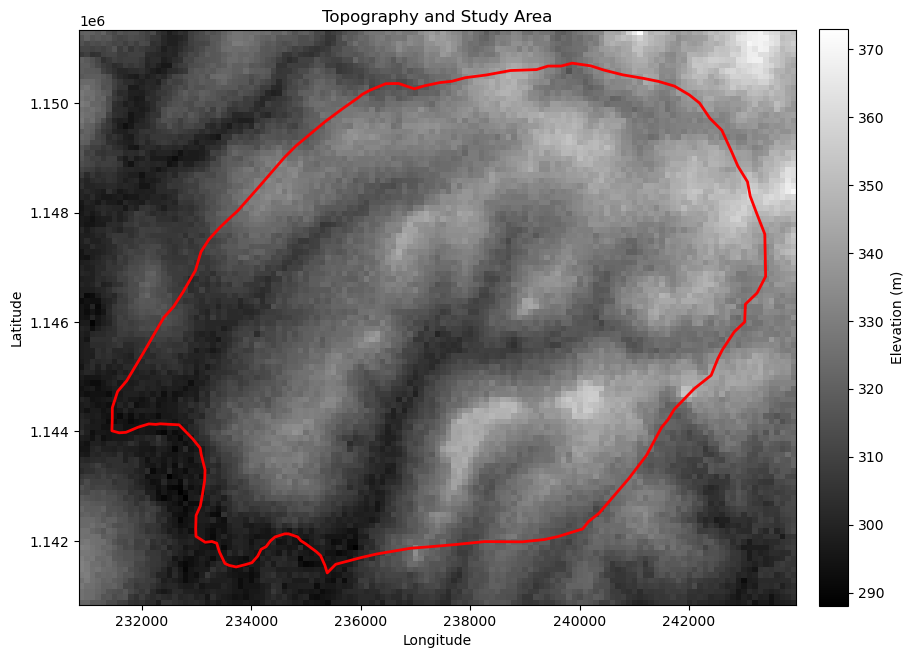

In [6]:
# Plot DEM and study area together
def plot_topo_and_study_area(topo_file, study_area):
    import rasterio
    from rasterio.plot import show

    with rasterio.open(topo_file) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        show(src, ax=ax, cmap='grey')
        im = ax.images[0]
        study_area.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
        ax.set_title('Topography and Study Area')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        fig.colorbar(
            im,
            ax=ax,
            label='Elevation (m)',
            shrink=0.75,
            fraction=0.045,
            pad=0.03,
        )
        plt.show()
plot_topo_and_study_area(topo_file, study_area)

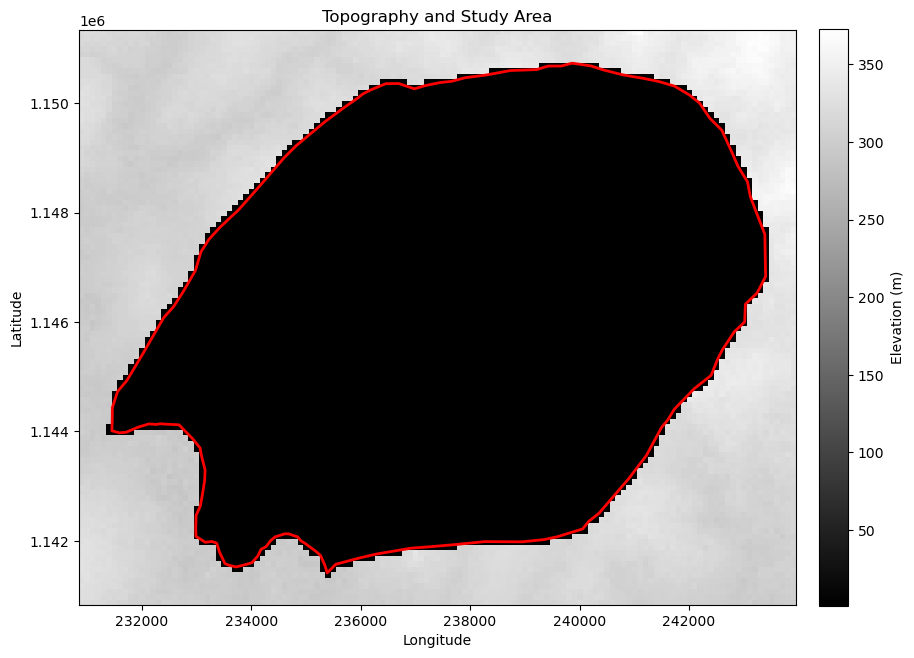

In [7]:

# Make a copy of the topo raster and change values that fall inside the study area to 1
with rasterio.open(topo_file) as src:
    study_area_proj = study_area.to_crs(src.crs)
    topo_data = src.read(1).copy()
    mask = geometry_mask(
        study_area_proj.geometry,
        invert=True,
        transform=src.transform,
        out_shape=src.shape,
        all_touched=True,
    )
    topo_data[mask] = 1
    topo_profile = src.profile

# Save the modified raster to a new file and plot it
# Also save an ascii version of the modified raster for use in MODFLOW

topo_copy_path = os.path.join(processed_gis_dir, 'topo_copy.tif')
# topo_copy_path = os.path.join(data_dir, 'topo_copy.asc')
with rasterio.open(topo_copy_path, 'w', **topo_profile) as dst:
    dst.write(topo_data, 1)

plot_topo_and_study_area(topo_copy_path, study_area)




In [8]:

# Open the input raster file
src_ds = gdal.Open(topo_copy_path)
# Use Translate to convert to Arc/Info ASCII Grid format
outasc = topo_copy_path.replace('.tif', '.asc')
print(f"Converting {topo_copy_path} to {outasc}...")
gdal.Translate(outasc, src_ds, format='AAIGrid')


Converting c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\topo_copy.tif to c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\topo_copy.asc...


c:\Users\mouss\mambaforge\envs\gis\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x0000021DDDD4D740> >

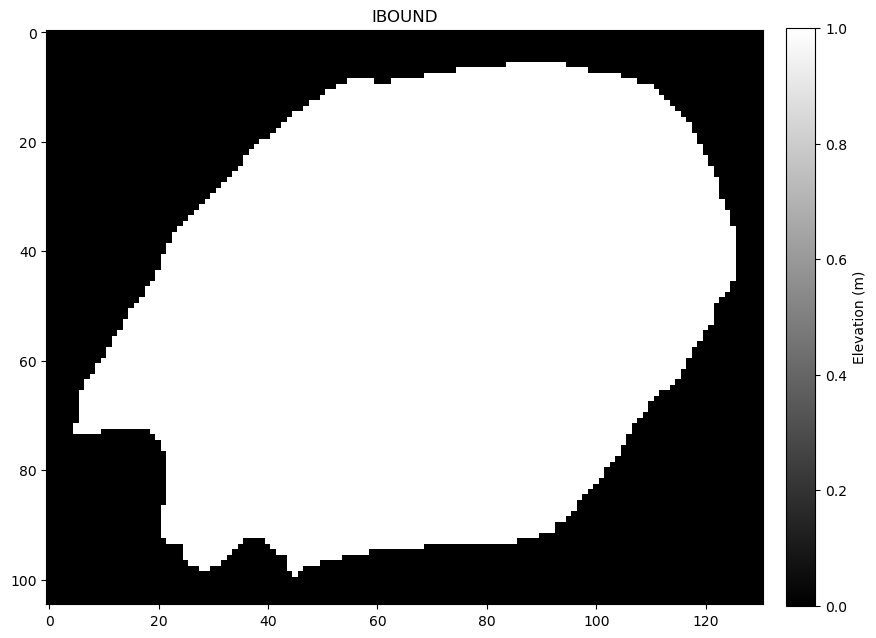

In [9]:
ascii_file = os.path.join(processed_gis_dir, 'topo_copy.asc')
topoasc = np.loadtxt(ascii_file, skiprows=6)  # Skip the header lines
topoasc[topoasc != 1] = 0  # Set masked values to 0 for better visualization
np.savetxt(os.path.join(processed_gis_dir, 'topo_copy_processed.dat'), topoasc, fmt='%d')  # Save processed ASCII grid
fig, ax = plt.subplots(figsize=(10, 10))
im = plt.imshow(topoasc, cmap='gray')
plt.imshow(topoasc, cmap='gray')
plt.title('IBOUND')
# plt.colorbar()
fig.colorbar(
            im,
            ax=ax,
            label='Elevation (m)',
            shrink=0.75,
            fraction=0.045,
            pad=0.03,)

In [10]:
shapefiles = [f for f in os.listdir(os.path.join(data_dir, '..', 'gisfiles')) if f.endswith('.shp')]

In [11]:


# ---------------------------------------------------------
# USER INPUTS
# ---------------------------------------------------------
tif_path = topo_file
out_shp = os.path.join(processed_gis_dir, 'minet01_bbox.shp')

# ---------------------------------------------------------
# READ RASTER AND GET BOUNDS
# ---------------------------------------------------------
with rasterio.open(tif_path) as src:
    bounds = src.bounds
    crs = src.crs

# bounds = (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bounds

# ---------------------------------------------------------
# CREATE POLYGON OF THE BOUNDING BOX
# ---------------------------------------------------------
bbox_poly = box(minx, miny, maxx, maxy)

# ---------------------------------------------------------
# SAVE AS SHAPEFILE
# ---------------------------------------------------------
gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[bbox_poly], crs=crs)
gdf.to_file(out_shp)

print("Bounding box shapefile created:")
print("  →", out_shp)
print("Raster bounds:", bounds)


Bounding box shapefile created:
  → c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\minet01_bbox.shp
Raster bounds: BoundingBox(left=230855.88263463654, bottom=1140833.9130020207, right=243955.88263463654, top=1151333.9130020207)


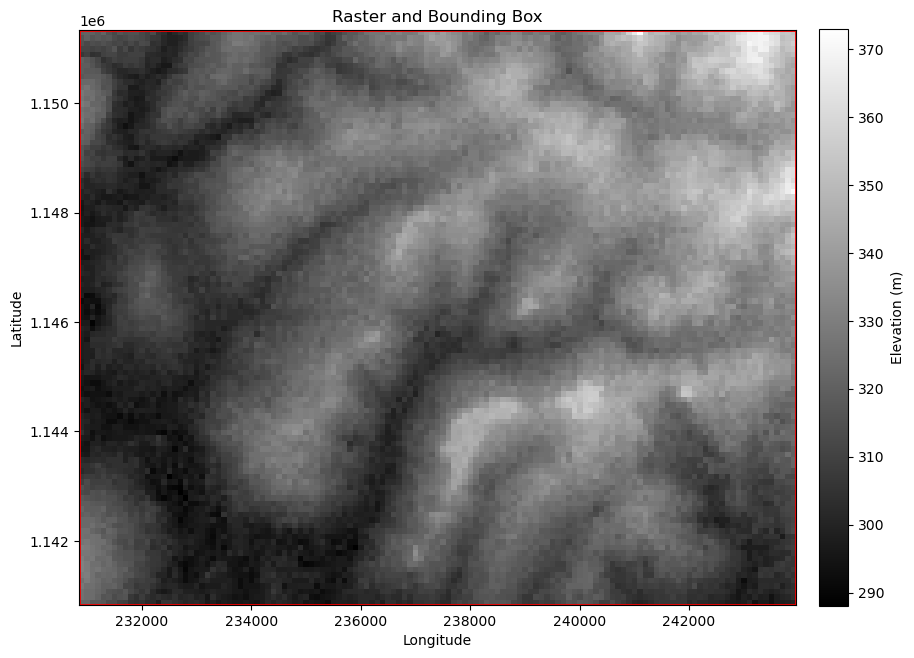

In [12]:
# Plot the raster and bounding box together
def plot_raster_and_bbox(tif_path, bbox_shp):
    import rasterio
    from rasterio.plot import show

    with rasterio.open(tif_path) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        show(src, ax=ax, cmap='grey')
        im = ax.images[0]
        bbox_gdf = gpd.read_file(bbox_shp)
        bbox_gdf.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
        ax.set_title('Raster and Bounding Box')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        fig.colorbar(
            im,
            ax=ax,
            label='Elevation (m)',
            shrink=0.75,
            fraction=0.045,
            pad=0.03,
        )
        plt.show()
plot_raster_and_bbox(tif_path, out_shp)

In [13]:
def clip_shapefile(input_shp, clipper_shp, output_shp):
    """
    Clip a shapefile using another shapefile (polygon clipper).

    Parameters
    ----------
    input_shp : str
        Path to the shapefile to be clipped.
    clipper_shp : str
        Path to the polygon shapefile used as the clipping boundary.
    output_shp : str
        Path where the clipped shapefile will be saved.

    Returns
    -------
    geopandas.GeoDataFrame
        The clipped GeoDataFrame.
    """

    # Read input and clipper shapefiles
    gdf_in = gpd.read_file(input_shp)
    gdf_clip = gpd.read_file(clipper_shp)

    # Ensure CRS match
    if gdf_in.crs != gdf_clip.crs:
        gdf_clip = gdf_clip.to_crs(gdf_in.crs)

    # Perform clipping
    clipped = gpd.clip(gdf_in, gdf_clip)

    # Save output
    clipped.to_file(output_shp)

    print(f"Clipped shapefile saved to: {output_shp}")
    print(f"Features in clipped layer: {len(clipped)}")

    return clipped


In [14]:
# clip all shapefiles in the gisfiles directory using the bounding box shapefile
shapefiles = [f for f in os.listdir(gis_dir) if f.endswith('.shp')]
shapefiles


['Fosse nogbele 2.1.shp',
 'Fosse nogbele 2.2.shp',
 'Fosse nogbele 2.3.shp',
 'HYD_Cours_eau.shp',
 'HYD_Digue.shp',
 'HYD_Point_eau.shp',
 'HYD_Surface_eau.shp',
 'HYD_Zone_humide.shp',
 'WGN_GEOL_20K_0312_THRUSTS_LN.shp',
 'WGN_SIMPLIFIED_GEOL_20K_STRUCTURES_LN.shp']

In [15]:
bbox_shp = os.path.join(processed_gis_dir, 'minet01_bbox.shp')
for shp in shapefiles:
    print(f"Clipping {shp} using {bbox_shp}...")
    input_shp = os.path.join(gis_dir, shp)
    base = os.path.splitext(shp)[0]         
    output_shp = os.path.join(processed_gis_dir, f"{base}_clip.shp")
    clip_shapefile(input_shp, bbox_shp, output_shp)

Clipping Fosse nogbele 2.1.shp using c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\minet01_bbox.shp...
Clipped shapefile saved to: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\Fosse nogbele 2.1_clip.shp
Features in clipped layer: 1
Clipping Fosse nogbele 2.2.shp using c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\minet01_bbox.shp...
Clipped shapefile saved to: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\Fosse nogbele 2.2_clip.shp
Features in clipped layer: 1
Clipping Fosse nogbele 2.3.shp using c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\minet01_bbox.shp...
Clipped shapefile saved to: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\Fosse nogbele 2.3_clip.shp
Features in clipped layer: 1
Clipping HYD_Cours_eau.shp using c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\minet01_bbox.shp...

c:\Users\mouss\mambaforge\envs\gis\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


In [16]:
shapefiles

['Fosse nogbele 2.1.shp',
 'Fosse nogbele 2.2.shp',
 'Fosse nogbele 2.3.shp',
 'HYD_Cours_eau.shp',
 'HYD_Digue.shp',
 'HYD_Point_eau.shp',
 'HYD_Surface_eau.shp',
 'HYD_Zone_humide.shp',
 'WGN_GEOL_20K_0312_THRUSTS_LN.shp',
 'WGN_SIMPLIFIED_GEOL_20K_STRUCTURES_LN.shp']

Processing Fosse nogbele 2.1.shp...


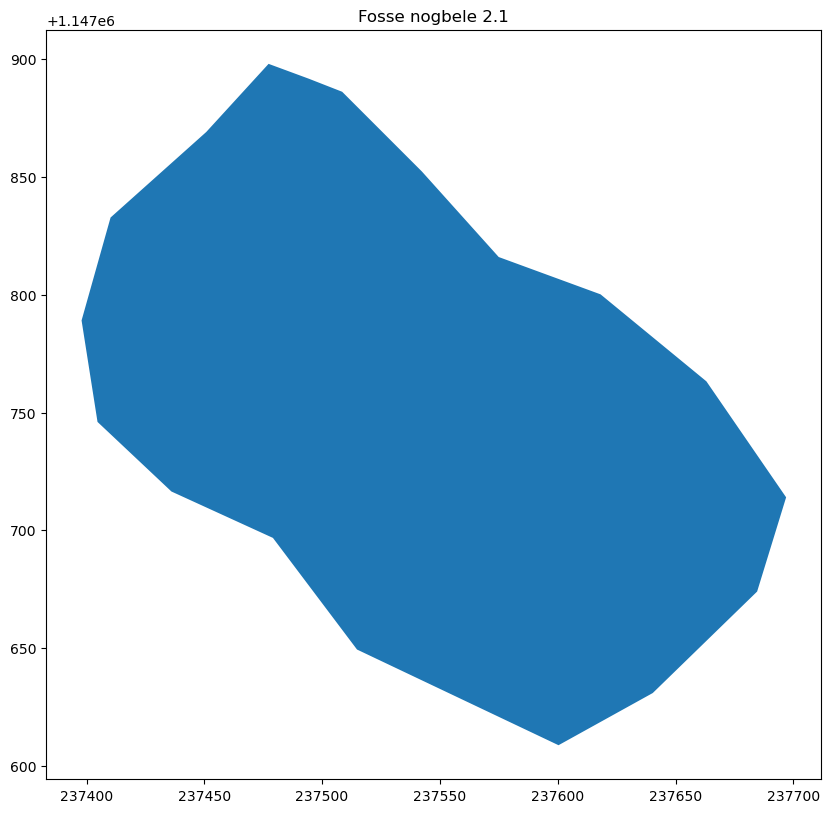

Processing Fosse nogbele 2.2.shp...


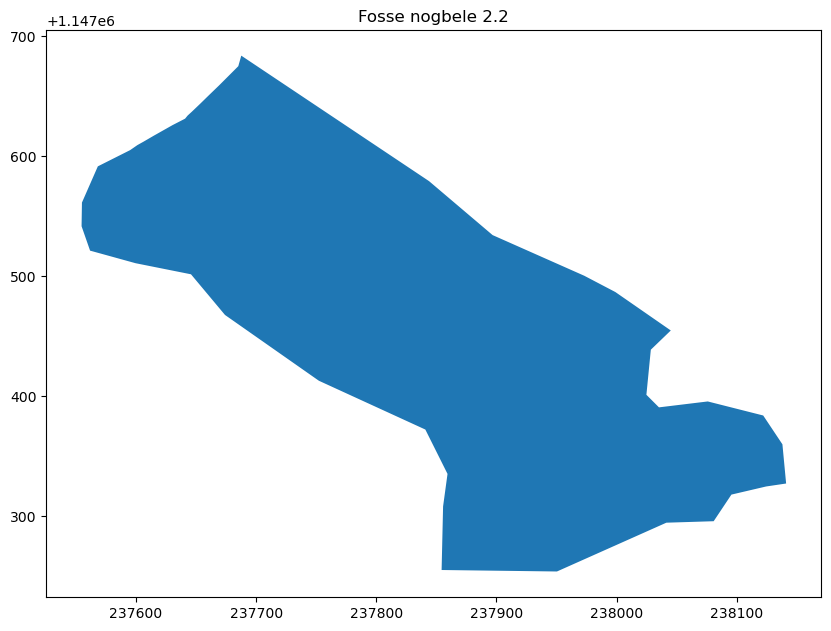

Processing Fosse nogbele 2.3.shp...


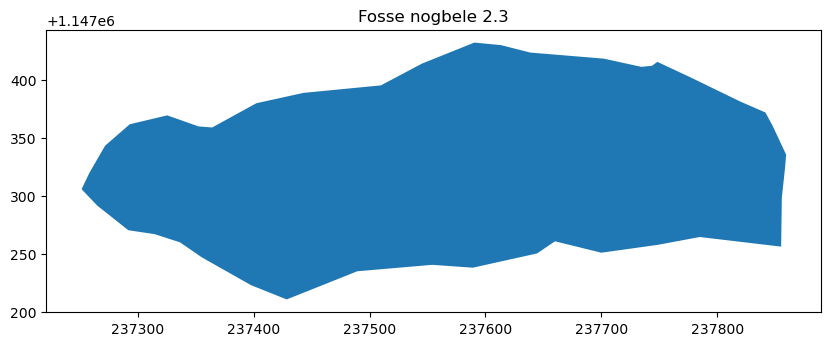

Processing HYD_Cours_eau.shp...


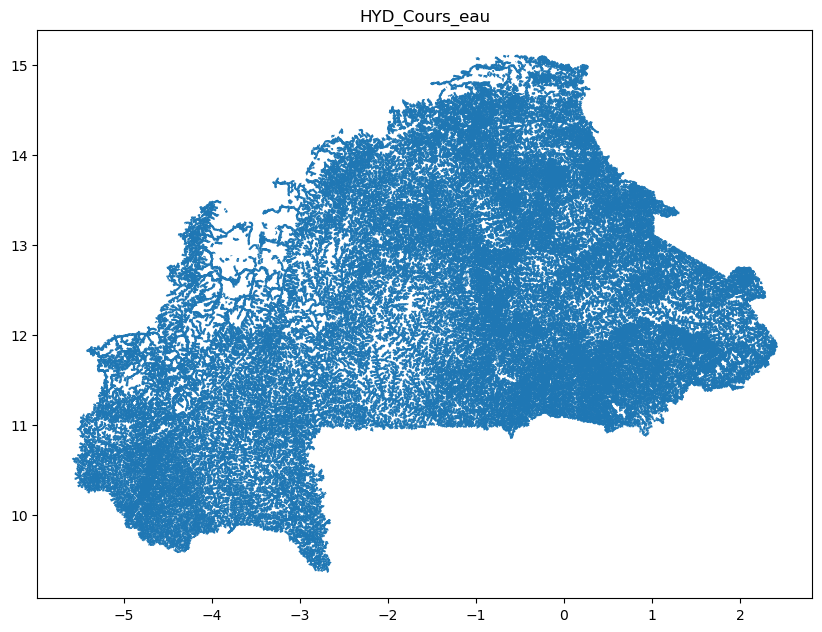

Processing HYD_Digue.shp...


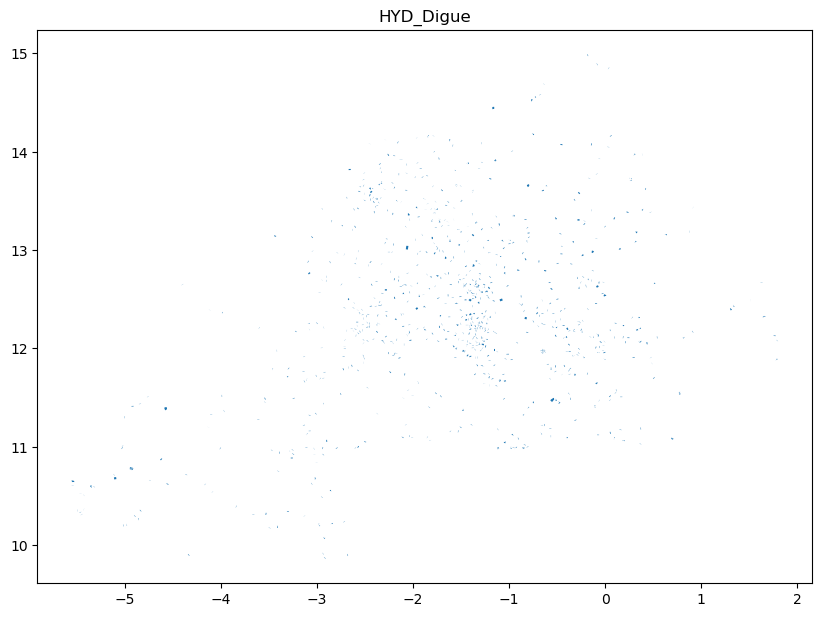

Processing HYD_Point_eau.shp...


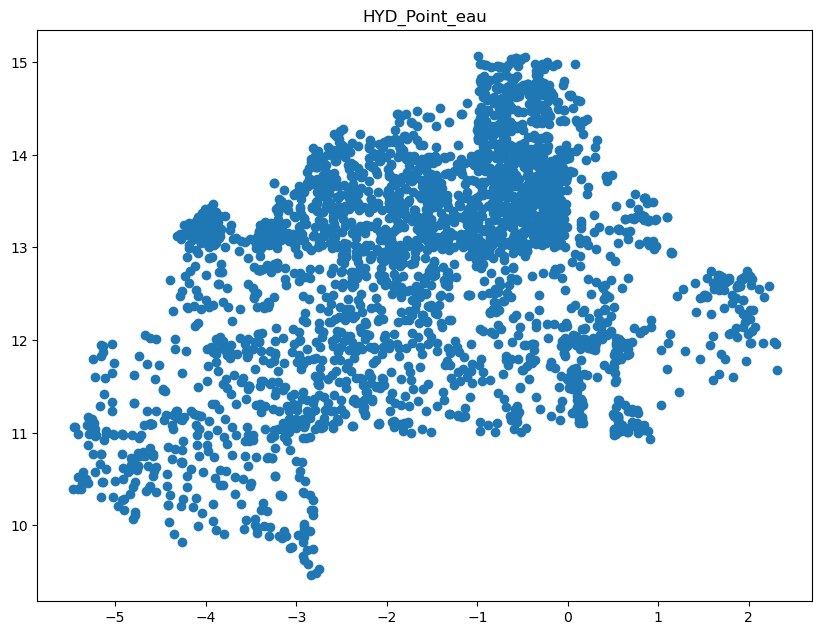

Processing HYD_Surface_eau.shp...


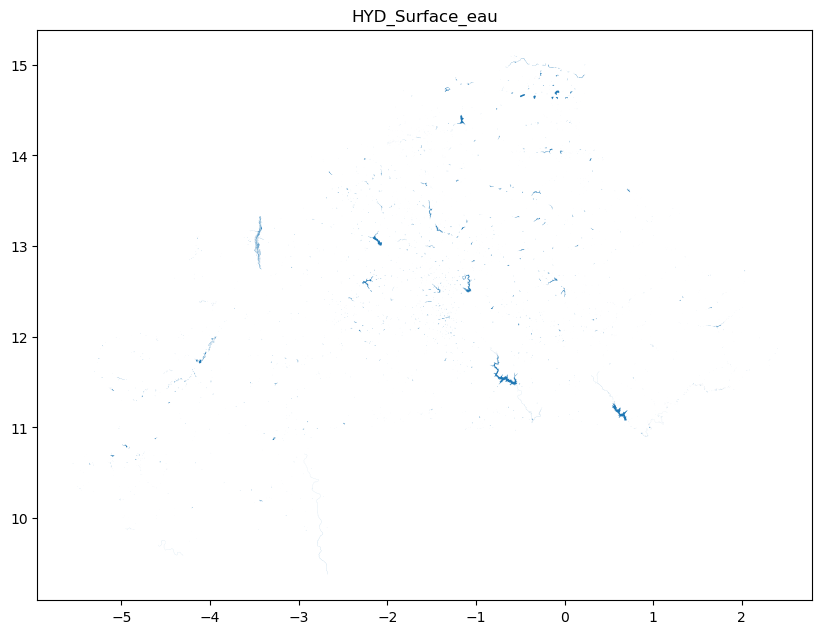

Processing HYD_Zone_humide.shp...


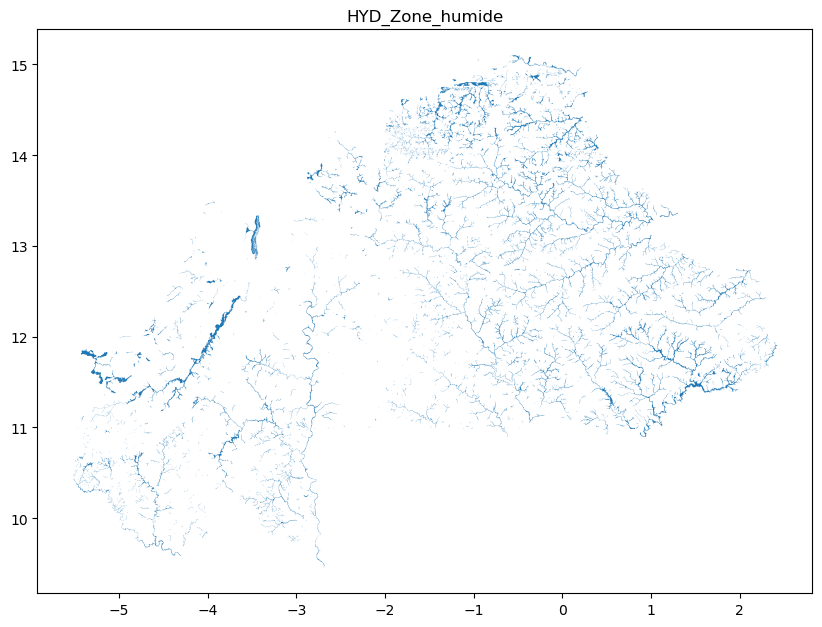

Processing WGN_GEOL_20K_0312_THRUSTS_LN.shp...


c:\Users\mouss\mambaforge\envs\gis\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


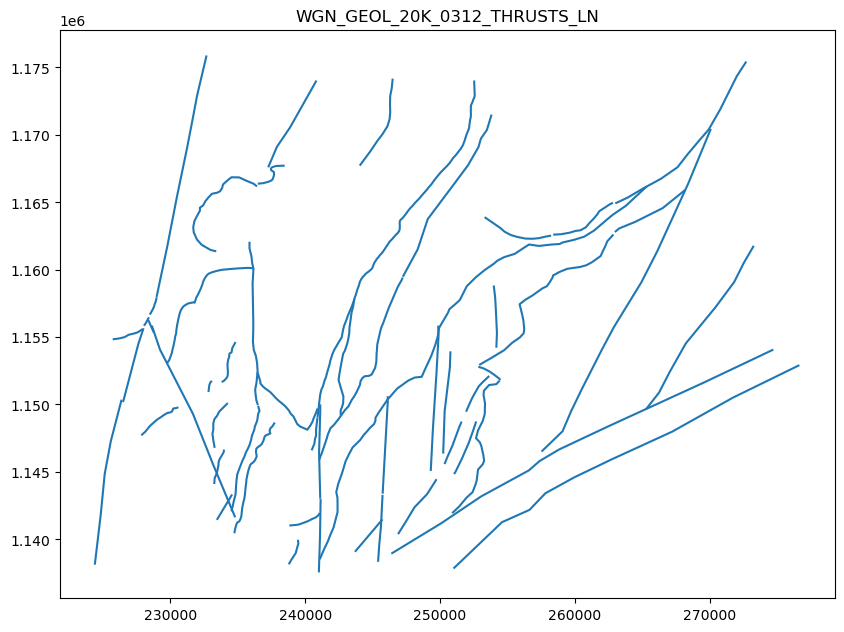

Processing WGN_SIMPLIFIED_GEOL_20K_STRUCTURES_LN.shp...


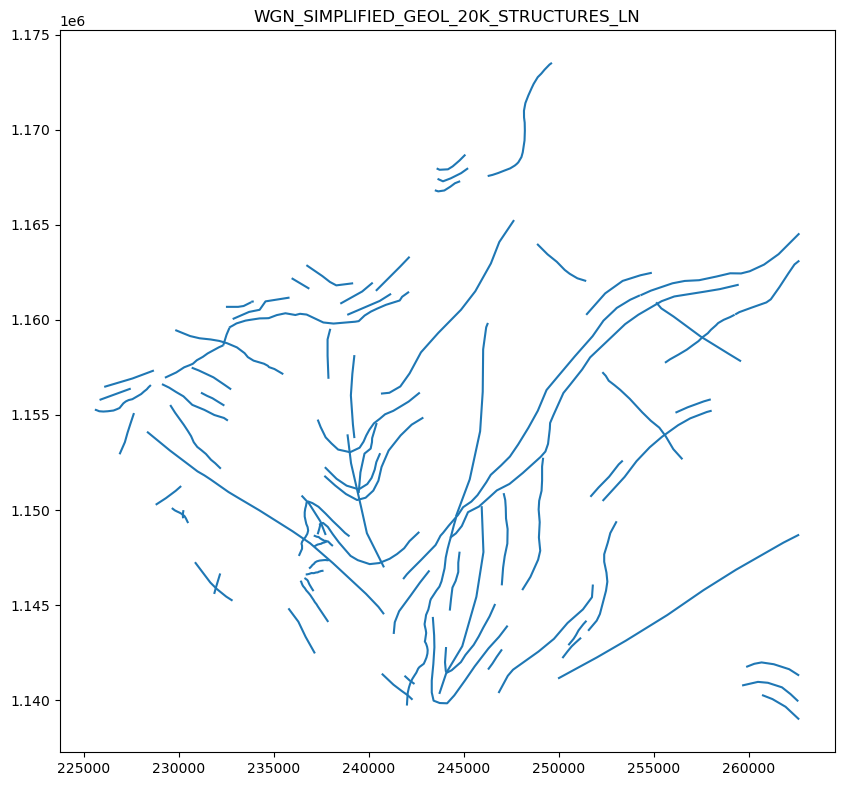

In [17]:
for shp in shapefiles:
    fig, ax = plt.subplots(figsize=(10, 10))
    print(f"Processing {shp}...")
    gdf = gpd.read_file(os.path.join(data_dir, '..', 'gisfiles', shp))
    gdf.plot(ax=ax)
    ax.set_title(os.path.splitext(shp)[0])
    plt.show()


In [18]:
hydrology_shp = os.path.join(processed_gis_dir, 'HYD_Cours_eau_clip.shp')

In [19]:
def plot_focus(tif_path, bbox_shp, hydrology_shp):
    import rasterio
    from rasterio.plot import show
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # Open raster
    with rasterio.open(tif_path) as src:
        fig, ax = plt.subplots(figsize=(10, 10))

        # Plot raster
        show(src, ax=ax, cmap='gray')
        im = ax.images[0]

        # Read shapefiles
        bbox_gdf = gpd.read_file(bbox_shp)
        hyd_gdf = gpd.read_file(hydrology_shp)

        # Ensure CRS match
        if bbox_gdf.crs != hyd_gdf.crs:
            hyd_gdf = hyd_gdf.to_crs(bbox_gdf.crs)

        # Plot hydrology and bounding box
        hyd_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2)
        bbox_gdf.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)

        # Labels and colorbar
        ax.set_title('Raster and Bounding Box')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        fig.colorbar(
            im,
            ax=ax,
            label='Elevation (m)',
            shrink=0.75,
            fraction=0.045,
            pad=0.03,
        )

        plt.show()


Text(0.5, 1.0, 'Hydrology Shapefile (Clipped)')

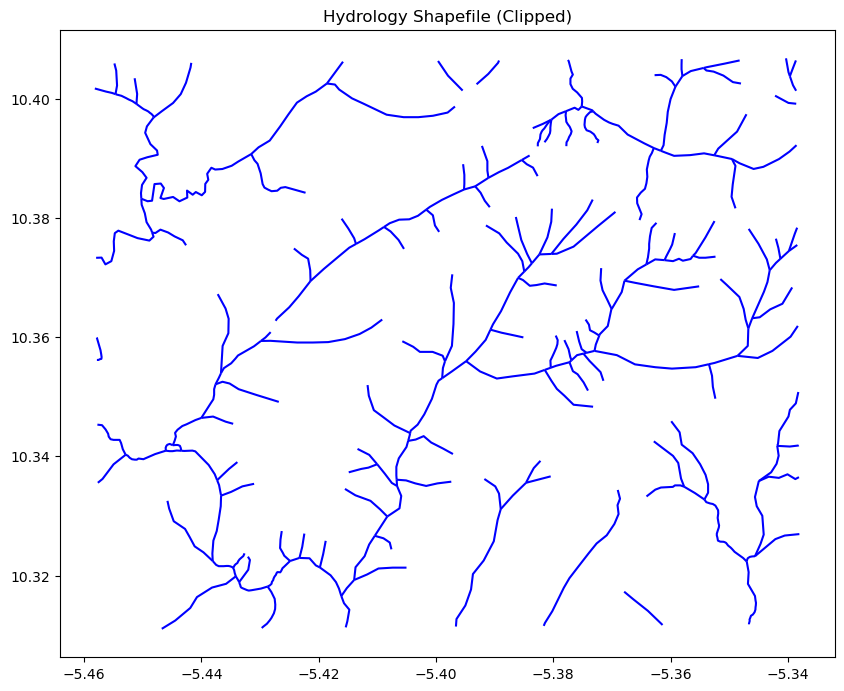

In [20]:
# Plot hydrology shapefile alone to check it looks correct
gdf = gpd.read_file(hydrology_shp)
gdf.plot(figsize=(10, 10), edgecolor='blue', facecolor='none')
plt.title('Hydrology Shapefile (Clipped)')


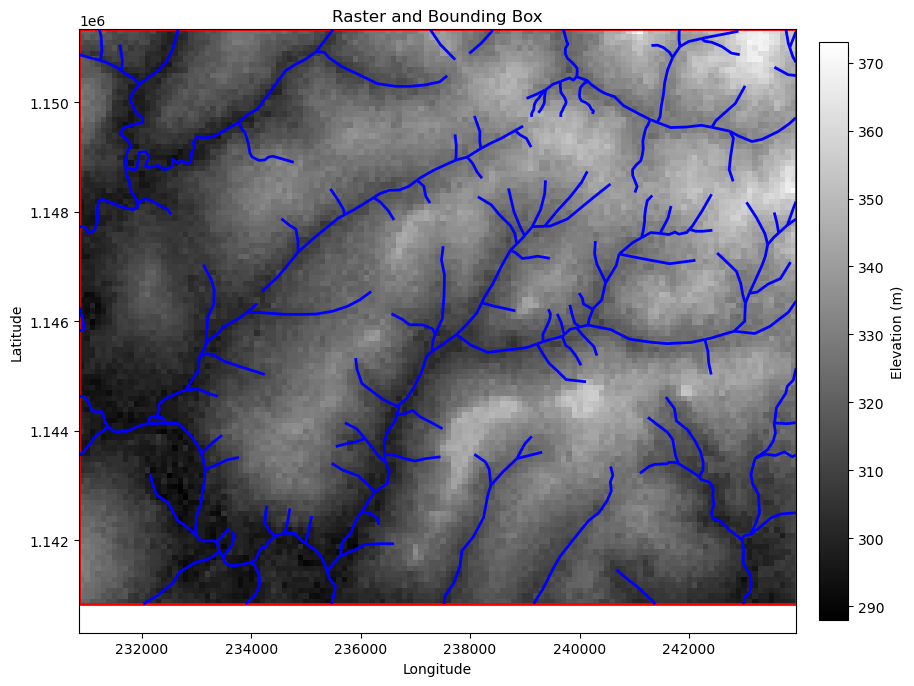

In [21]:
plot_focus(tif_path, out_shp, hydrology_shp)

In [22]:
import rasterio
from shapely.geometry import box
import geopandas as gpd
import os

# Path to the topo raster
topo_raster_path = topo_file  # Assuming topo_file is defined earlier

# Open the raster and get bounds
with rasterio.open(topo_raster_path) as src:
    bounds = src.bounds
    crs = src.crs

# Create bounding box polygon
bbox_poly = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

# Create GeoDataFrame
gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[bbox_poly], crs=crs)

# Output shapefile path
topo_bbox_shp = os.path.join(processed_gis_dir, 'topo_bbox.shp')

# Save to shapefile
gdf.to_file(topo_bbox_shp)

print(f"Bounding box shapefile saved to: {topo_bbox_shp}")

Bounding box shapefile saved to: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\topo_bbox.shp


In [35]:
import numpy as np
from shapely.geometry import Polygon

# Define cell size (in meters, assuming projected CRS)
cell_size = 100  # Adjust as needed

# Get bounds from topo raster
with rasterio.open(topo_file) as src:
    bounds = src.bounds
    crs = src.crs

minx, miny, maxx, maxy = bounds.left, bounds.bottom, bounds.right, bounds.top

# Calculate number of rows and columns
ncols = int(np.ceil((maxx - minx) / cell_size))
nrows = int(np.ceil((maxy - miny) / cell_size))

# Create grid polygons and attributes
polygons = []
rows = []
cols = []
mfrowcols = []
for i in range(nrows):
    for j in range(ncols):
        x1 = minx + j * cell_size
        y1 = miny + i * cell_size
        x2 = minx + (j + 1) * cell_size
        y2 = miny + (i + 1) * cell_size
        poly = Polygon([(x1, y1), (x2, y1), (x2, y2), (x1, y2)])
        polygons.append(poly)
        row = i + 1  # 1-based row
        col = j + 1  # 1-based column
        rows.append(row)
        cols.append(col)
        mfrowcols.append(1000 * row + col)

# Create GeoDataFrame
grid_gdf = gpd.GeoDataFrame({
    "id": range(len(polygons)),
    "row": rows,
    "col": cols,
    "mfrowcol": mfrowcols
}, geometry=polygons, crs=crs)

# Output shapefile path
grid_shp = os.path.join(processed_gis_dir, 'topo_grid.shp')

# Save to shapefile
grid_gdf.to_file(grid_shp)

print(f"Grid shapefile saved to: {grid_shp}")
print(f"Number of grid cells: {len(polygons)}")

Grid shapefile saved to: c:\Users\mouss\modeling\gitrepo\mine-t01\scripts\..\gisfiles\processed_gis\topo_grid.shp
Number of grid cells: 13755


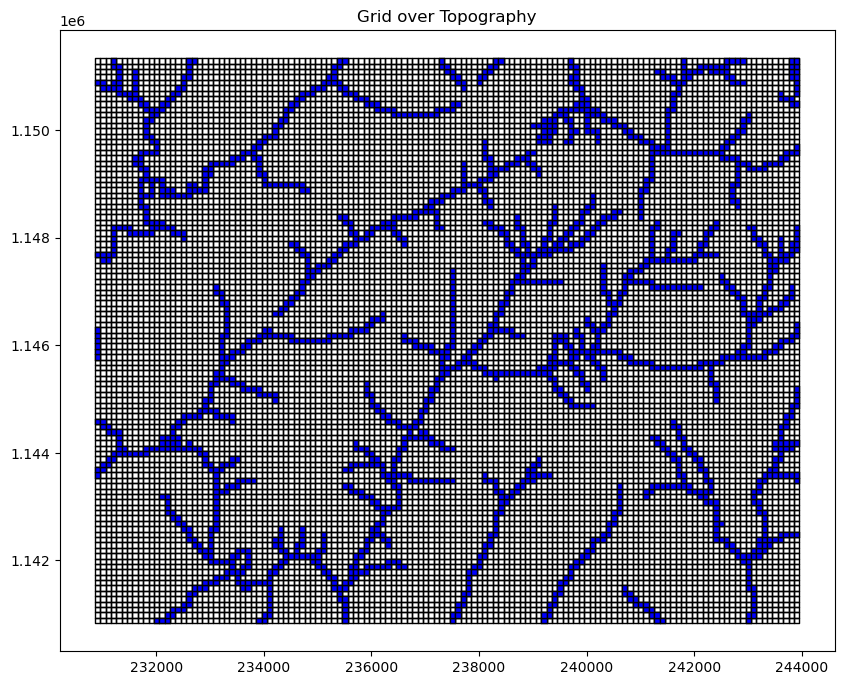

In [43]:
# Plot the grid to check it looks correct
ax = grid_gdf.plot(figsize=(10, 10), edgecolor='black', facecolor='none')
grid_gdf[grid_gdf['riv'] == 1].plot(ax=ax, facecolor='blue', edgecolor='black')
plt.title('Grid over Topography')
plt.show()

In [37]:
grid_gdf.shape

(13755, 5)

In [38]:
grid_gdf.head(15)

,id,row,col,mfrowcol,geometry
0,0,1,1,1001,"POLYGON ((230855.883 1140833.913, 230955.883 1..."
1,1,1,2,1002,"POLYGON ((230955.883 1140833.913, 231055.883 1..."
2,2,1,3,1003,"POLYGON ((231055.883 1140833.913, 231155.883 1..."
3,3,1,4,1004,"POLYGON ((231155.883 1140833.913, 231255.883 1..."
4,4,1,5,1005,"POLYGON ((231255.883 1140833.913, 231355.883 1..."
5,5,1,6,1006,"POLYGON ((231355.883 1140833.913, 231455.883 1..."
6,6,1,7,1007,"POLYGON ((231455.883 1140833.913, 231555.883 1..."
7,7,1,8,1008,"POLYGON ((231555.883 1140833.913, 231655.883 1..."
8,8,1,9,1009,"POLYGON ((231655.883 1140833.913, 231755.883 1..."
9,9,1,10,1010,"POLYGON ((231755.883 1140833.913, 231855.883 1..."


In [40]:
# Add a "riv" field to the grid shapefile and set it to 1 for cells that intersect the hydrology shapefile, 0 otherwise
grid_gdf['riv'] = 0  # Initialize with 0

# Load hydrology shapefile
hydrology_gdf = gpd.read_file(hydrology_shp)

# Ensure CRS match
if grid_gdf.crs != hydrology_gdf.crs:
    hydrology_gdf = hydrology_gdf.to_crs(grid_gdf.crs)

hydro_union = hydrology_gdf.geometry.unary_union
grid_gdf['riv'] = grid_gdf.geometry.intersects(hydro_union).astype(int)

grid_gdf.to_file(grid_shp)
print(grid_gdf['riv'].sum())

C:\Users\mouss\AppData\Local\Temp\ipykernel_28936\2379222204.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydrology_gdf.geometry.unary_union


1822


In [41]:
grid_gdf.head()

,id,row,col,mfrowcol,geometry,riv
0,0,1,1,1001,"POLYGON ((230855.883 1140833.913, 230955.883 1...",0
1,1,1,2,1002,"POLYGON ((230955.883 1140833.913, 231055.883 1...",0
2,2,1,3,1003,"POLYGON ((231055.883 1140833.913, 231155.883 1...",0
3,3,1,4,1004,"POLYGON ((231155.883 1140833.913, 231255.883 1...",0
4,4,1,5,1005,"POLYGON ((231255.883 1140833.913, 231355.883 1...",0


In [ ]:
# Add fields "topo" for the elevation in each grid cell based on the topo raster, 


with rasterio.open(topo_file) as src:
    topo_data = src.read(1)
    transform = src.transform
def get_raster_value(geom, raster_data, transform):
    from rasterio.features import geometry_mask
    import numpy as np

    # Create a mask for the geometry
    mask = geometry_mask([geom], transform=transform, invert=True, out_shape=raster_data.shape)

    # Get the mean value of the raster data within the geometry
    if np.any(mask):
        return raster_data[mask].mean()
    else:
        return np.nan  # Return NaN if no pixels intersect
grid_gdf['topo'] = grid_gdf.geometry.apply(lambda geom: get_raster_value(geom, topo_data, transform))
grid_gdf.head()

,id,row,col,mfrowcol,geometry,riv,topo
0,0,1,1,1001,"POLYGON ((230855.883 1140833.913, 230955.883 1...",0,322.0
1,1,1,2,1002,"POLYGON ((230955.883 1140833.913, 231055.883 1...",0,322.0
2,2,1,3,1003,"POLYGON ((231055.883 1140833.913, 231155.883 1...",0,318.0
3,3,1,4,1004,"POLYGON ((231155.883 1140833.913, 231255.883 1...",0,318.0
4,4,1,5,1005,"POLYGON ((231255.883 1140833.913, 231355.883 1...",0,317.0


In [47]:
# and "ibound" for the ibound value (based on the study area shapefile) 
# in each grid cell based on the modified topo raster where values inside 
# the study area are 1 and outside are 0 
# (the "ibound" field should be set to 1 for cells that intersect the study area,
#  0 otherwise).
with rasterio.open(topo_copy_path) as src:
    ibound_data = src.read(1)
    transform = src.transform
grid_gdf['ibound'] = grid_gdf.geometry.apply(lambda geom: get_raster_value(geom, ibound_data, transform))
grid_gdf['ibound'] = grid_gdf['ibound'].apply(lambda x: 1 if x == 1 else 0)
grid_gdf.head()


,id,row,col,mfrowcol,geometry,riv,topo,ibound
0,0,1,1,1001,"POLYGON ((230855.883 1140833.913, 230955.883 1...",0,322.0,0
1,1,1,2,1002,"POLYGON ((230955.883 1140833.913, 231055.883 1...",0,322.0,0
2,2,1,3,1003,"POLYGON ((231055.883 1140833.913, 231155.883 1...",0,318.0,0
3,3,1,4,1004,"POLYGON ((231155.883 1140833.913, 231255.883 1...",0,318.0,0
4,4,1,5,1005,"POLYGON ((231255.883 1140833.913, 231355.883 1...",0,317.0,0
